# Proyecto Final — Analítica y Visualización de Datos
### Análisis Multivariado y Espectral

**Dataset:** Concentraciones de Contaminantes — SEDEMA / SIMAT, CDMX  
**Archivo:** `rama_2023_05.csv`  
**Periodo:** 01/01/2015 — 31/05/2023

---
### Contenido
1. Carga y preparación de datos
2. Análisis de Componentes Principales (PCA)
3. Escalamiento Multidimensional (MDS)
4. Mapeo de Sammon
5. Análisis Espectral (Fourier)
6. Estimación de Correlación

## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga y preparación de datos

In [2]:
# Carga del dataset original
df = pd.read_csv('rama_2023_05.csv', parse_dates=['fecha'], dayfirst=True)

CONTAMINANTES = ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2']

# Columnas de tiempo
df['anio']     = df['fecha'].dt.year
df['mes']      = df['fecha'].dt.month
df['anio_mes'] = df['fecha'].dt.to_period('M')
df['estacion_anio'] = pd.cut(
    df['mes'], bins=[0, 3, 6, 9, 12],
    labels=['Invierno', 'Primavera', 'Verano', 'Otoño']
)

# Matriz M: perfiles mensuales (101 meses × 8 contaminantes)
M = df.groupby('anio_mes')[CONTAMINANTES].mean()

# Metadatos de cada mes para colorear las gráficas
meta = df.groupby('anio_mes').agg(
    anio=('anio', 'first'),
    mes=('mes', 'first'),
    estacion=('estacion_anio', 'first')
).reset_index()
meta['estacion'] = meta['estacion'].astype(str)

# Estandarización Z-score (obligatoria: contaminantes en distintas unidades)
scaler = StandardScaler()
M_std  = scaler.fit_transform(M)

print(f'Matriz M lista: {M.shape[0]} meses × {M.shape[1]} contaminantes')
print(f'Estandarizada: media ≈ 0, std ≈ 1 por columna ')

Matriz M lista: 101 meses × 8 contaminantes
Estandarizada: media ≈ 0, std ≈ 1 por columna ✓


## 2. Análisis de Componentes Principales (PCA)

PCA busca las direcciones de máxima varianza en el espacio de 8 contaminantes
y proyecta los 101 perfiles mensuales en un espacio de menor dimensión.

**Interpretación:** cada punto en el biplot es un mes.  
Meses cercanos → perfil de contaminación similar.  
Las flechas (loadings) indican cuánto contribuye cada contaminante a cada componente.

In [3]:
# Ajuste del PCA
pca = PCA()
scores = pca.fit_transform(M_std)   # Puntuaciones (101 meses en el nuevo espacio)
loadings = pca.components_          # Loadings (contribución de cada contaminante)
varianza = pca.explained_variance_ratio_

print('Varianza explicada por componente:')
for i, v in enumerate(varianza):
    acum = varianza[:i+1].sum()
    bar  = '█' * int(v * 50)
    print(f'  PC{i+1}: {v*100:5.2f}%  (acumulada: {acum*100:5.2f}%)  {bar}')

n_comp_90 = np.argmax(np.cumsum(varianza) >= 0.90) + 1
print(f'\nComponentes necesarias para explicar ≥90% de varianza: {n_comp_90}')

Varianza explicada por componente:
  PC1: 68.70%  (acumulada: 68.70%)  ██████████████████████████████████
  PC2: 20.86%  (acumulada: 89.56%)  ██████████
  PC3:  5.11%  (acumulada: 94.67%)  ██
  PC4:  3.17%  (acumulada: 97.84%)  █
  PC5:  1.14%  (acumulada: 98.98%)  
  PC6:  0.73%  (acumulada: 99.71%)  
  PC7:  0.28%  (acumulada: 100.00%)  
  PC8:  0.00%  (acumulada: 100.00%)  

Componentes necesarias para explicar ≥90% de varianza: 3


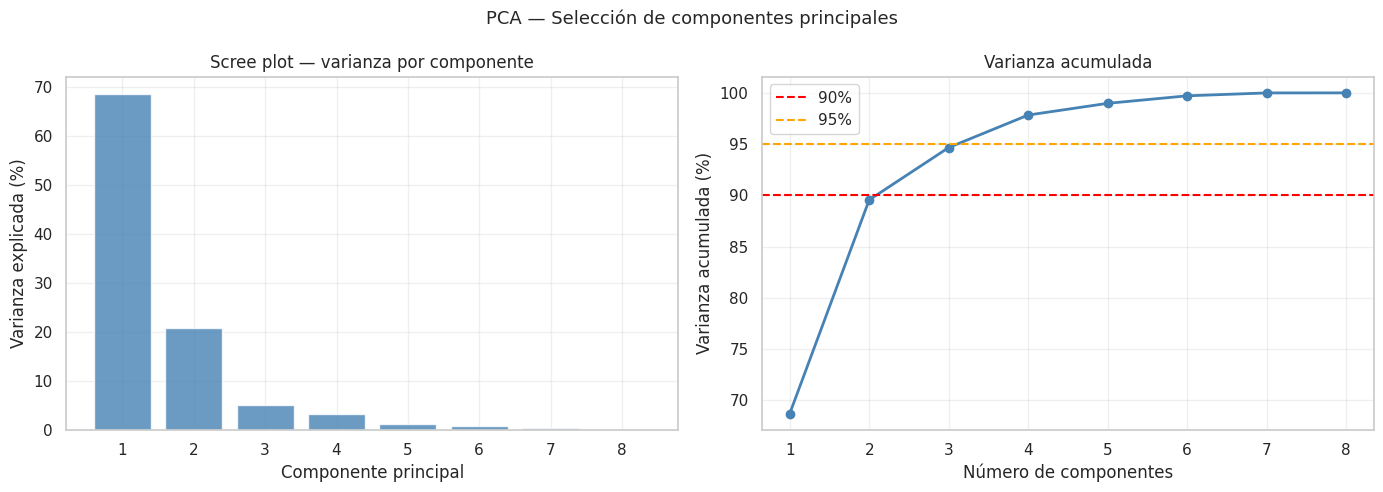

Figura guardada: fig_pca_scree.png


In [4]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
axes[0].bar(range(1, len(varianza)+1), varianza*100, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot — varianza por componente')
axes[0].set_xticks(range(1, len(varianza)+1))

# Varianza acumulada
acum = np.cumsum(varianza) * 100
axes[1].plot(range(1, len(acum)+1), acum, marker='o', color='steelblue', lw=2)
axes[1].axhline(90, color='red', linestyle='--', lw=1.5, label='90%')
axes[1].axhline(95, color='orange', linestyle='--', lw=1.5, label='95%')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(acum)+1))
axes[1].legend()

plt.suptitle('PCA — Selección de componentes principales', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_pca_scree.png')

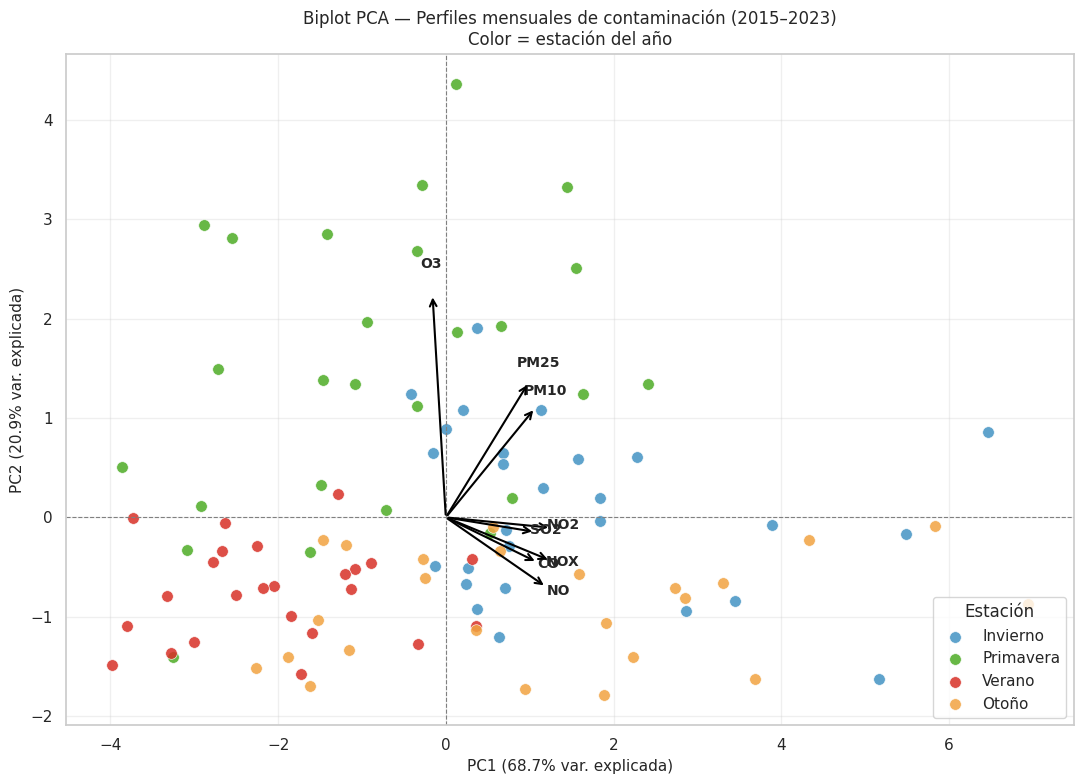

Figura guardada: fig_pca_biplot.png


In [5]:
# Biplot PC1 vs PC2 coloreado por estación del año
colores_estacion = {'Invierno': '#4393c3', 'Primavera': '#4dac26',
                    'Verano': '#d73027', 'Otoño': '#f1a340'}

fig, ax = plt.subplots(figsize=(11, 8))

# Puntos (scores)
for estacion, color in colores_estacion.items():
    idx = meta['estacion'] == estacion
    ax.scatter(scores[idx, 0], scores[idx, 1],
               c=color, label=estacion, alpha=0.85, s=70, edgecolors='white', lw=0.5)

# Flechas de loadings escaladas
escala = 3.0
for j, cont in enumerate(CONTAMINANTES):
    ax.annotate('', xy=(loadings[0, j]*escala, loadings[1, j]*escala), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings[0, j]*escala*1.12, loadings[1, j]*escala*1.12,
            cont, fontsize=10, fontweight='bold', ha='center')

ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
ax.set_xlabel(f'PC1 ({varianza[0]*100:.1f}% var. explicada)', fontsize=11)
ax.set_ylabel(f'PC2 ({varianza[1]*100:.1f}% var. explicada)', fontsize=11)
ax.set_title('Biplot PCA — Perfiles mensuales de contaminación (2015–2023)\nColor = estación del año', fontsize=12)
ax.legend(title='Estación', loc='lower right')
plt.tight_layout()
plt.savefig('fig_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_pca_biplot.png')

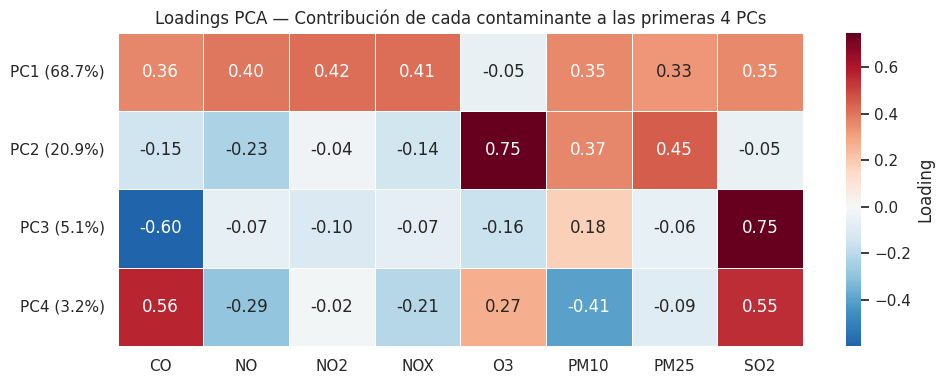

Interpretación de PC1 y PC2:
  PC1 está dominada por: NO2
  PC2 está dominada por: O3


In [6]:
# Heatmap de loadings
loadings_df = pd.DataFrame(
    loadings[:4],
    index=[f'PC{i+1} ({varianza[i]*100:.1f}%)' for i in range(4)],
    columns=CONTAMINANTES
).round(3)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(loadings_df, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Loading'})
ax.set_title('Loadings PCA — Contribución de cada contaminante a las primeras 4 PCs', fontsize=12)
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretación de PC1 y PC2:')
pc1_dom = loadings_df.loc['PC1 ({:.1f}%)'.format(varianza[0]*100)].abs().idxmax()
pc2_dom = loadings_df.loc['PC2 ({:.1f}%)'.format(varianza[1]*100)].abs().idxmax()
print(f'  PC1 está dominada por: {pc1_dom}')
print(f'  PC2 está dominada por: {pc2_dom}')

## 3. Escalamiento Multidimensional (MDS)

MDS proyecta los perfiles mensuales en 2D **preservando las distancias**
entre meses lo mejor posible. A diferencia de PCA, no asume linealidad.

Usamos la **matriz de distancias euclidianas** calculada en el notebook de preprocesamiento.

In [7]:
# MDS métrico (basado en distancias euclidianas)
dist_matrix = squareform(pdist(M_std, metric='euclidean'))

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
coords_mds = mds.fit_transform(dist_matrix)

stress = mds.stress_
print(f'MDS Stress: {stress:.4f}')
print()
# Criterio de Kruskal para interpretar el stress
if stress < 0.025:
    calidad = 'Excelente'
elif stress < 0.05:
    calidad = 'Buena'
elif stress < 0.10:
    calidad = 'Aceptable'
else:
    calidad = 'Pobre'
print(f'Calidad del ajuste (criterio de Kruskal): {calidad}')

MDS Stress: 899.6129

Calidad del ajuste (criterio de Kruskal): Pobre


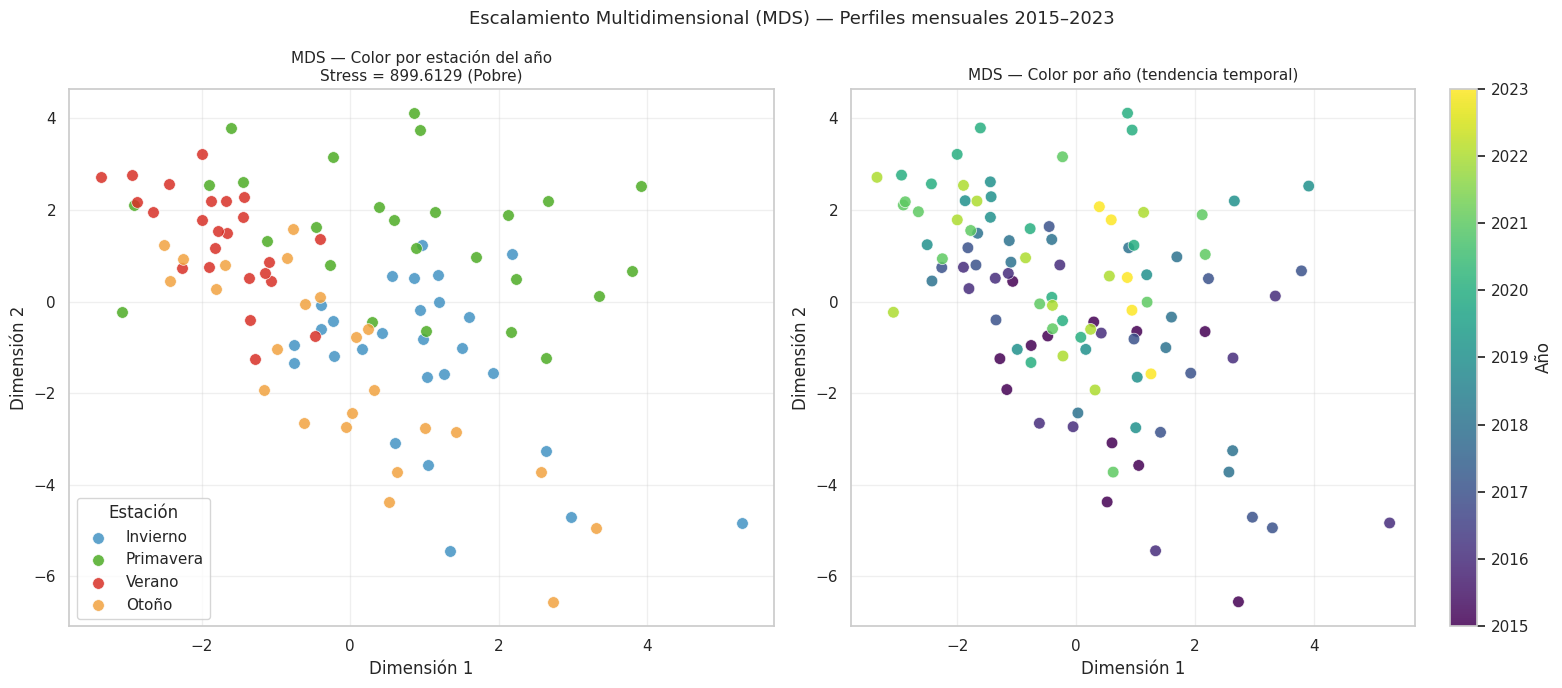

Figura guardada: fig_mds.png


In [8]:
# Visualización MDS coloreado por estación
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Por estación del año
ax = axes[0]
for estacion, color in colores_estacion.items():
    idx = meta['estacion'] == estacion
    ax.scatter(coords_mds[idx, 0], coords_mds[idx, 1],
               c=color, label=estacion, alpha=0.85, s=70, edgecolors='white', lw=0.5)
ax.set_title(f'MDS — Color por estación del año\nStress = {stress:.4f} ({calidad})', fontsize=11)
ax.set_xlabel('Dimensión 1')
ax.set_ylabel('Dimensión 2')
ax.legend(title='Estación')

# Por año (gradiente de color)
ax = axes[1]
anios = meta['anio'].values
sc = ax.scatter(coords_mds[:, 0], coords_mds[:, 1],
                c=anios, cmap='viridis', alpha=0.85, s=70, edgecolors='white', lw=0.5)
plt.colorbar(sc, ax=ax, label='Año')
ax.set_title('MDS — Color por año (tendencia temporal)', fontsize=11)
ax.set_xlabel('Dimensión 1')
ax.set_ylabel('Dimensión 2')

plt.suptitle('Escalamiento Multidimensional (MDS) — Perfiles mensuales 2015–2023', fontsize=13)
plt.tight_layout()
plt.savefig('fig_mds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_mds.png')

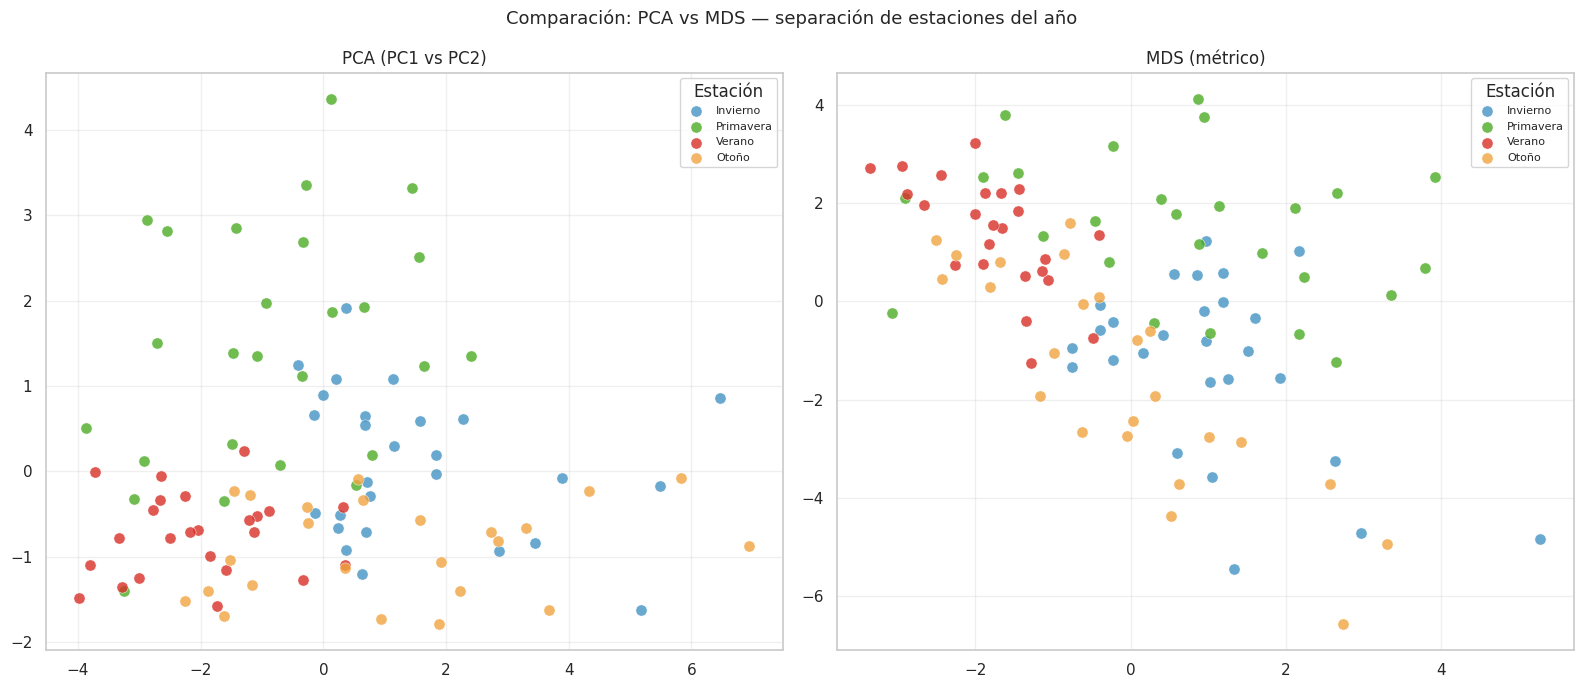

In [9]:
# Comparación PCA vs MDS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, titulo in zip(
    axes,
    [scores[:, :2], coords_mds],
    ['PCA (PC1 vs PC2)', 'MDS (métrico)']
):
    for estacion, color in colores_estacion.items():
        idx = meta['estacion'] == estacion
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=color, label=estacion, alpha=0.8, s=65, edgecolors='white', lw=0.4)
    ax.set_title(titulo, fontsize=12)
    ax.legend(title='Estación', fontsize=8)

plt.suptitle('Comparación: PCA vs MDS — separación de estaciones del año', fontsize=13)
plt.tight_layout()
plt.savefig('fig_pca_vs_mds.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Mapeo de Sammon

El mapeo de Sammon es una variante de MDS que **pondera más las distancias pequeñas**,
preservando mejor la estructura local del espacio original.

Minimiza la función de costo:  
$$E = \frac{1}{\sum_{i<j} d_{ij}} \sum_{i<j} \frac{(d_{ij} - \hat{d}_{ij})^2}{d_{ij}}$$

donde $d_{ij}$ es la distancia original y $\hat{d}_{ij}$ la distancia en 2D.

In [10]:
# Implementación del Mapeo de Sammon
def sammon_stress(coords_flat, dist_orig):
    """Función de costo de Sammon (para minimizar con scipy)."""
    n = dist_orig.shape[0]
    coords = coords_flat.reshape(n, 2)

    dist_proj = squareform(pdist(coords, metric='euclidean'))
    # Evitar división por cero en la diagonal
    mask = dist_orig > 1e-10

    numerador   = np.sum(((dist_orig[mask] - dist_proj[mask])**2) / dist_orig[mask])
    denominador = np.sum(dist_orig[mask])
    return numerador / denominador

# Inicializamos con las coordenadas MDS (acelera la convergencia)
coords_init = coords_mds.flatten()

print('Optimizando mapeo de Sammon...')
resultado = minimize(
    sammon_stress,
    coords_init,
    args=(dist_matrix,),
    method='L-BFGS-B',
    options={'maxiter': 500, 'ftol': 1e-9}
)

coords_sammon = resultado.x.reshape(-1, 2)
stress_sammon = resultado.fun

print(f'Convergencia: {resultado.success}')
print(f'Sammon stress final: {stress_sammon:.6f}')
print(f'MDS stress          : {stress:.6f}')
print(f'Diferencia          : {abs(stress - stress_sammon):.6f}')

Optimizando mapeo de Sammon...
Convergencia: True
Sammon stress final: 0.012527
MDS stress          : 899.612916
Diferencia          : 899.600389


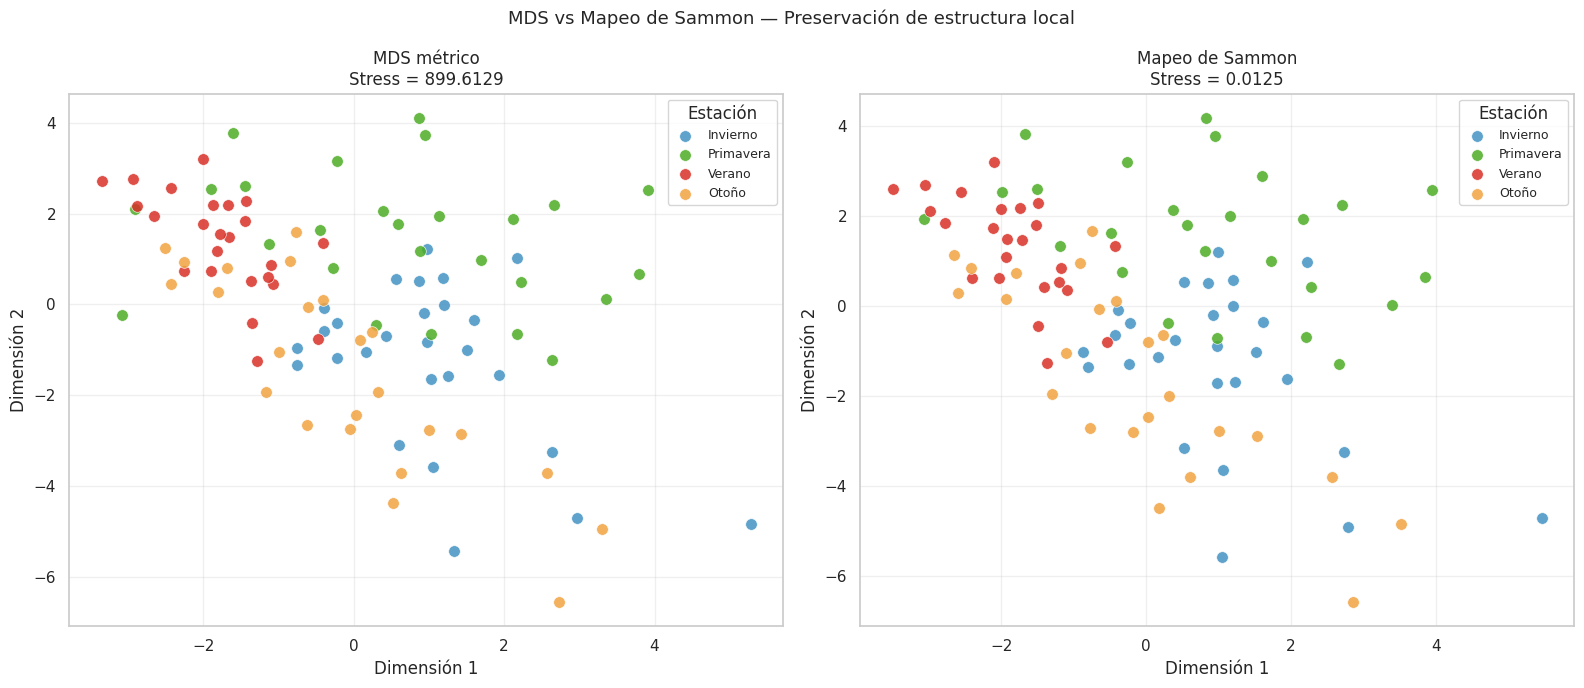

Figura guardada: fig_sammon.png

El Mapeo de Sammon pondera más las distancias pequeñas → mejor separación local.


In [11]:
# Visualización Sammon
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, coords, titulo, stress_val in zip(
    axes,
    [coords_mds, coords_sammon],
    ['MDS métrico', 'Mapeo de Sammon'],
    [stress, stress_sammon]
):
    for estacion, color in colores_estacion.items():
        idx = meta['estacion'] == estacion
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=color, label=estacion, alpha=0.85, s=70, edgecolors='white', lw=0.5)
    ax.set_title(f'{titulo}\nStress = {stress_val:.4f}', fontsize=12)
    ax.set_xlabel('Dimensión 1')
    ax.set_ylabel('Dimensión 2')
    ax.legend(title='Estación', fontsize=9)

plt.suptitle('MDS vs Mapeo de Sammon — Preservación de estructura local', fontsize=13)
plt.tight_layout()
plt.savefig('fig_sammon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_sammon.png')
print()
print('El Mapeo de Sammon pondera más las distancias pequeñas → mejor separación local.')

## 5. Análisis Espectral (Fourier)

Aplicamos la **Transformada de Fourier** a la serie temporal diaria de cada
contaminante para identificar los **ciclos dominantes** en la señal.

Hipótesis esperada:
- Ciclo **anual** (frecuencia = 1/365 días⁻¹): estacionalidad invierno/verano
- Ciclo **semianual** (frecuencia = 2/365 días⁻¹): picos en ciertas épocas del año
- Ciclo **semanal** (frecuencia = 1/7 días⁻¹): menos tráfico los fines de semana

Seguimos la convención del curso: retiramos la tendencia lineal antes de aplicar FFT.

In [12]:
# Función de análisis espectral
def analisis_espectral(serie, nombre, dt=1.0):
    """
    Calcula el espectro de potencia de una serie temporal.
    dt: intervalo de muestreo en días (dt=1 → datos diarios)
    Retorna: frecuencias, periodos, potencia
    """
    n = len(serie)

    # Retirar tendencia lineal (convención del curso)
    t = np.arange(n)
    coef = np.polyfit(t, serie, 1)
    tendencia = np.polyval(coef, t)
    serie_dt  = serie - tendencia

    # Aplicar ventana de Hann para reducir fugas espectrales
    ventana   = np.hanning(n)
    serie_win = serie_dt * ventana

    # FFT
    fft_vals  = np.fft.rfft(serie_win)
    freqs     = np.fft.rfftfreq(n, d=dt)    # frecuencias en ciclos/día
    potencia  = (np.abs(fft_vals) ** 2) / n  # densidad espectral de potencia
    periodos  = np.where(freqs > 0, 1.0 / freqs, np.inf)  # periodos en días

    return freqs, periodos, potencia, serie_dt, tendencia

# Calcular para todos los contaminantes
espectros = {}
for cont in CONTAMINANTES:
    serie = df[cont].values
    freqs, periodos, potencia, serie_dt, tendencia = analisis_espectral(serie, cont)
    espectros[cont] = {
        'freqs': freqs, 'periodos': periodos, 'potencia': potencia,
        'serie_dt': serie_dt, 'tendencia': tendencia
    }

print('Espectros calculados para todos los contaminantes ')

Espectros calculados para todos los contaminantes 


In [13]:
# Frecuencias dominantes para cada contaminante
print('Top 3 frecuencias dominantes por contaminante:')
print(f'{"Contaminante":12} {"Período (días)":>15} {"Frec. (1/día)":>14} {"Potencia":>10}')
print('-' * 55)

for cont in CONTAMINANTES:
    esp = espectros[cont]
    # Excluir frecuencia 0 (componente DC)
    mask = esp['freqs'] > 0
    pot  = esp['potencia'][mask]
    freq = esp['freqs'][mask]
    per  = esp['periodos'][mask]

    top3 = np.argsort(pot)[::-1][:3]
    for i, idx in enumerate(top3):
        etiqueta = cont if i == 0 else ''
        print(f'{etiqueta:12} {per[idx]:>15.1f} {freq[idx]:>14.5f} {pot[idx]:>10.2f}')
    print()

Top 3 frecuencias dominantes por contaminante:
Contaminante  Período (días)  Frec. (1/día)   Potencia
-------------------------------------------------------
CO                    3073.0        0.00033       2.03
                       341.4        0.00293       1.71
                       384.1        0.00260       1.59

NO                     384.1        0.00260    6985.08
                       341.4        0.00293    6197.87
                         7.0        0.14286    1655.03

NO2                    341.4        0.00293    3228.44
                       384.1        0.00260    3014.70
                       180.8        0.00553     780.07

NOX                    384.1        0.00260   19559.08
                       341.4        0.00293   18489.56
                         7.0        0.14286    4393.31

O3                     384.1        0.00260    9447.54
                       341.4        0.00293    7216.00
                       180.8        0.00553    1695.94

PM10        

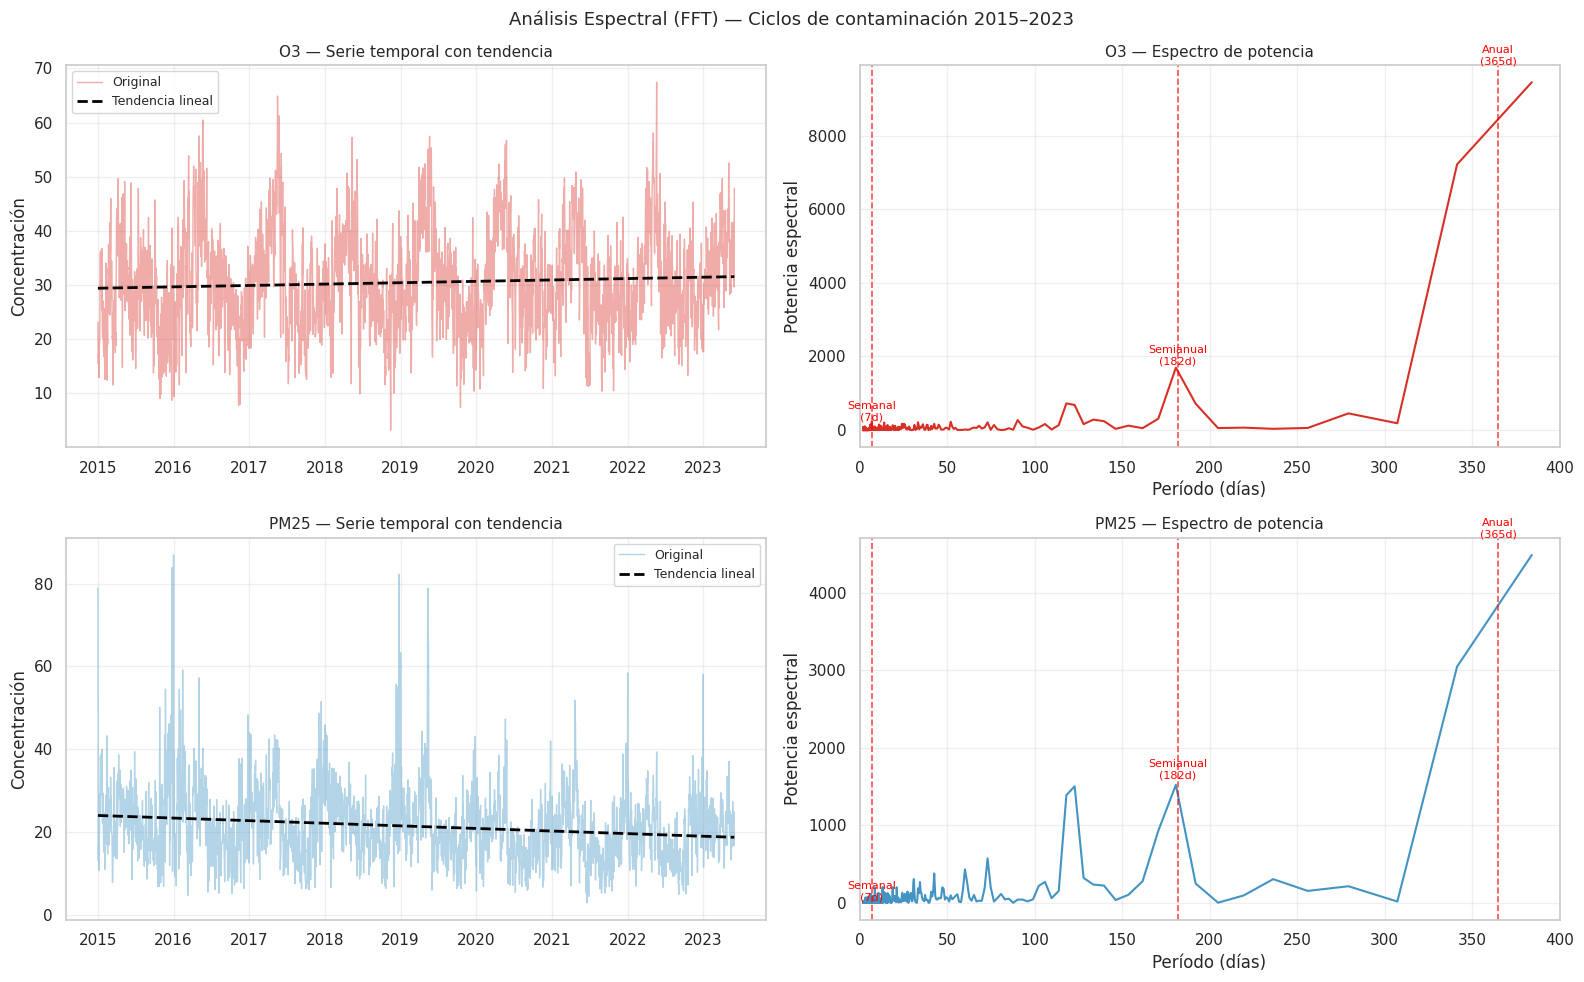

Figura guardada: fig_fourier.png


In [14]:
# Espectro de potencia: O3 y PM25 (contaminantes más representativos)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pares = [('O3', '#d73027'), ('PM25', '#4393c3')]

for row, (cont, color) in enumerate(pares):
    esp = espectros[cont]
    mask = (esp['freqs'] > 0) & (esp['periodos'] < 400)

    # Serie temporal con tendencia
    ax = axes[row, 0]
    t_fechas = df['fecha'].values
    ax.plot(t_fechas, df[cont].values, alpha=0.4, lw=1, color=color, label='Original')
    ax.plot(t_fechas, espectros[cont]['tendencia'] + df[cont].values - espectros[cont]['serie_dt'],
            lw=0, alpha=0)   # invisible, solo para alinear
    ax.plot(t_fechas, espectros[cont]['tendencia'] +
            df[cont].values.mean() - df[cont].values.mean() +
            espectros[cont]['tendencia'] * 0,
            lw=0)
    # Tendencia lineal
    n = len(df)
    t_num = np.arange(n)
    coef = np.polyfit(t_num, df[cont].values, 1)
    ax.plot(t_fechas, np.polyval(coef, t_num), lw=2, color='black',
            linestyle='--', label='Tendencia lineal')
    ax.set_title(f'{cont} — Serie temporal con tendencia', fontsize=11)
    ax.set_ylabel('Concentración')
    ax.legend(fontsize=9)

    # Espectro de potencia
    ax = axes[row, 1]
    periodos_plot = esp['periodos'][mask]
    potencia_plot = esp['potencia'][mask]
    ax.plot(periodos_plot, potencia_plot, color=color, lw=1.5)

    # Marcar ciclos conocidos
    for periodo, etiqueta in [(365, 'Anual\n(365d)'), (182, 'Semianual\n(182d)'), (7, 'Semanal\n(7d)')]:
        ax.axvline(periodo, color='red', linestyle='--', lw=1.2, alpha=0.7)
        pot_en_periodo = potencia_plot[np.argmin(np.abs(periodos_plot - periodo))]
        ax.text(periodo, pot_en_periodo * 1.05, etiqueta,
                color='red', fontsize=8, ha='center')

    ax.set_xlabel('Período (días)')
    ax.set_ylabel('Potencia espectral')
    ax.set_title(f'{cont} — Espectro de potencia', fontsize=11)
    ax.set_xlim(0, 400)

plt.suptitle('Análisis Espectral (FFT) — Ciclos de contaminación 2015–2023', fontsize=13)
plt.tight_layout()
plt.savefig('fig_fourier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_fourier.png')

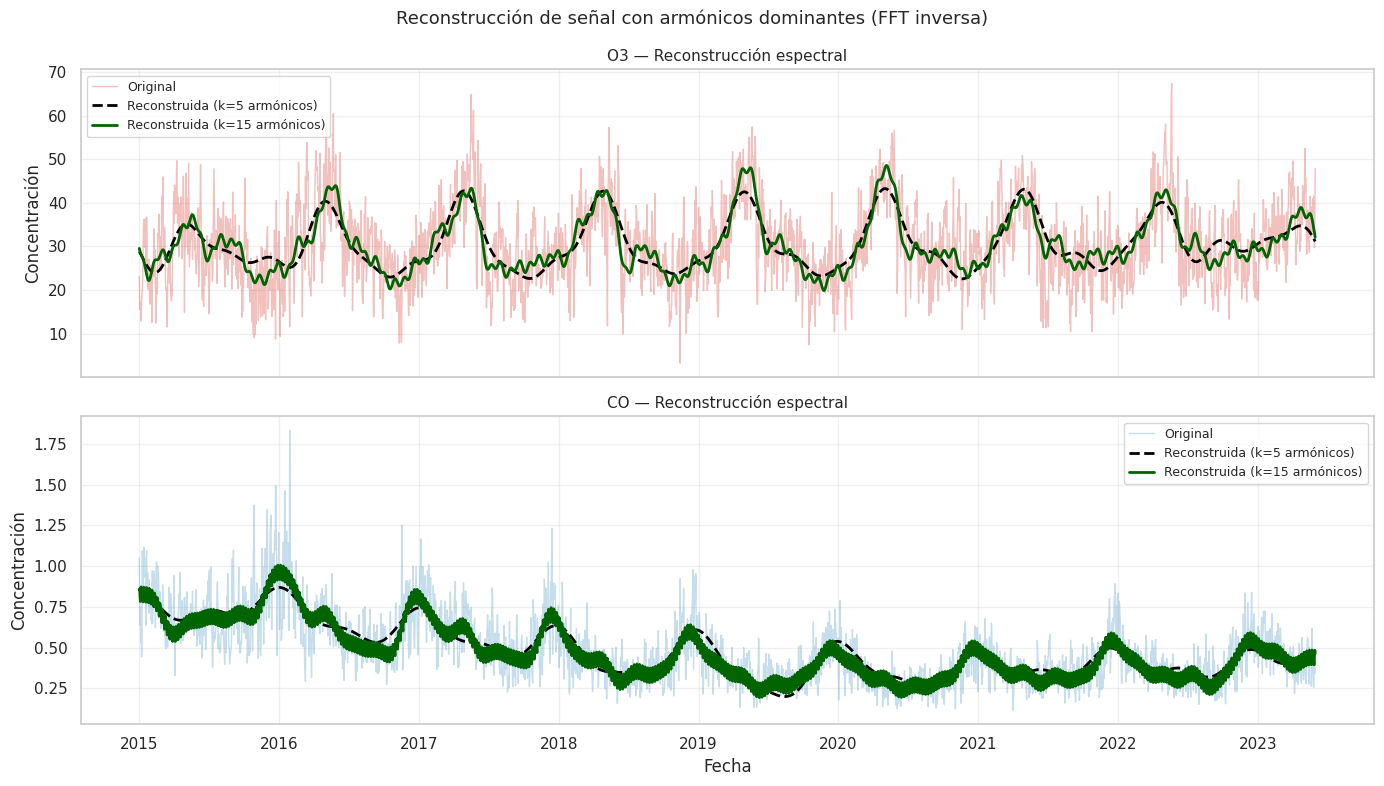

Figura guardada: fig_fourier_reconstruccion.png


In [15]:
# Reconstrucción de la señal con los k armónicos dominantes
def reconstruir_serie(serie, k=5):
    """
    Reconstruye la serie usando solo los k armónicos de mayor potencia.
    Permite visualizar cuánto de la variación original capturan los ciclos principales.
    """
    n = len(serie)
    t = np.arange(n)
    coef = np.polyfit(t, serie, 1)
    tendencia = np.polyval(coef, t)
    serie_dt  = serie - tendencia

    fft_vals = np.fft.rfft(serie_dt)
    potencia = np.abs(fft_vals) ** 2
    top_k    = np.argsort(potencia)[::-1][:k]

    fft_filtrado = np.zeros_like(fft_vals)
    fft_filtrado[top_k] = fft_vals[top_k]

    reconstruida = np.fft.irfft(fft_filtrado, n=n) + tendencia
    return reconstruida

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, cont, color in zip(axes, ['O3', 'CO'], ['#d73027', '#4393c3']):
    serie = df[cont].values
    rec5  = reconstruir_serie(serie, k=5)
    rec15 = reconstruir_serie(serie, k=15)

    ax.plot(df['fecha'], serie, alpha=0.3, lw=1, color=color, label='Original')
    ax.plot(df['fecha'], rec5,  lw=2, color='black', linestyle='--', label='Reconstruida (k=5 armónicos)')
    ax.plot(df['fecha'], rec15, lw=2, color='darkgreen', linestyle='-', label='Reconstruida (k=15 armónicos)')
    ax.set_ylabel('Concentración')
    ax.set_title(f'{cont} — Reconstrucción espectral', fontsize=11)
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Fecha')
plt.suptitle('Reconstrucción de señal con armónicos dominantes (FFT inversa)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_fourier_reconstruccion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_fourier_reconstruccion.png')

## 6. Estimación de Correlación

Analizamos las relaciones lineales entre contaminantes usando:
- **Correlación de Pearson** + prueba de hipótesis (H₀: ρ = 0)
- **Matriz de dispersión** para relaciones no lineales
- **Correlación con desfase temporal** (cross-correlation) entre contaminantes clave

In [16]:
# Matriz de correlación de Pearson con p-values
n = len(df)
corr_matrix = df[CONTAMINANTES].corr(method='pearson')

# Calcular p-values para cada par
p_matrix = pd.DataFrame(np.ones((len(CONTAMINANTES), len(CONTAMINANTES))),
                         index=CONTAMINANTES, columns=CONTAMINANTES)
for i, c1 in enumerate(CONTAMINANTES):
    for j, c2 in enumerate(CONTAMINANTES):
        if i != j:
            r, p = stats.pearsonr(df[c1], df[c2])
            p_matrix.loc[c1, c2] = p

print('Matriz de correlación de Pearson:')
print(corr_matrix.round(3))
print()
# Correlaciones significativas (p < 0.05)
sig = [(c1, c2, corr_matrix.loc[c1, c2], p_matrix.loc[c1, c2])
       for c1 in CONTAMINANTES for c2 in CONTAMINANTES
       if c1 < c2 and p_matrix.loc[c1, c2] < 0.05]
sig.sort(key=lambda x: abs(x[2]), reverse=True)

print(f'Pares con correlación significativa (p < 0.05): {len(sig)}')
print(f'{"Par":15} {"r":>8} {"p-value":>12}')
print('-' * 38)
for c1, c2, r, p in sig[:10]:
    print(f'{c1}–{c2:10} {r:>8.3f} {p:>12.2e}')

Matriz de correlación de Pearson:
         CO     NO    NO2    NOX     O3   PM10   PM25    SO2
CO    1.000  0.799  0.846  0.860 -0.073  0.545  0.534  0.310
NO    0.799  1.000  0.788  0.959 -0.242  0.527  0.354  0.268
NO2   0.846  0.788  1.000  0.929  0.042  0.705  0.650  0.430
NOX   0.860  0.959  0.929  1.000 -0.121  0.644  0.512  0.356
O3   -0.073 -0.242  0.042 -0.121  1.000  0.406  0.436 -0.031
PM10  0.545  0.527  0.705  0.644  0.406  1.000  0.858  0.461
PM25  0.534  0.354  0.650  0.512  0.436  0.858  1.000  0.471
SO2   0.310  0.268  0.430  0.356 -0.031  0.461  0.471  1.000

Pares con correlación significativa (p < 0.05): 27
Par                    r      p-value
--------------------------------------
NO–NOX           0.959     0.00e+00
NO2–NOX           0.929     0.00e+00
CO–NOX           0.860     0.00e+00
PM10–PM25          0.858     0.00e+00
CO–NO2           0.846     0.00e+00
CO–NO            0.799     0.00e+00
NO–NO2           0.788     0.00e+00
NO2–PM10          0.705     0.00e

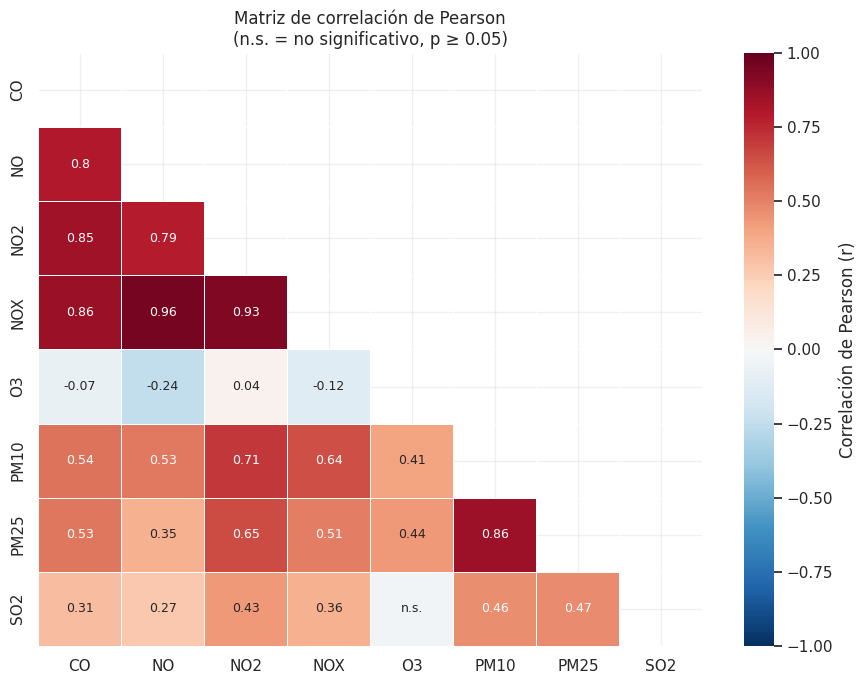

Figura guardada: fig_correlacion_heatmap.png


In [17]:
# Heatmap de correlación con anotación de significancia
# Máscara para el triángulo superior
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Anotaciones: r si significativo, 'n.s.' si no
annot = corr_matrix.round(2).astype(str)
for c1 in CONTAMINANTES:
    for c2 in CONTAMINANTES:
        if c1 != c2 and p_matrix.loc[c1, c2] >= 0.05:
            annot.loc[c1, c2] = 'n.s.'

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, mask=mask_tri, cmap='RdBu_r', center=0,
            annot=annot, fmt='', linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlación de Pearson (r)'},
            annot_kws={'size': 9})
ax.set_title('Matriz de correlación de Pearson\n(n.s. = no significativo, p ≥ 0.05)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_correlacion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_correlacion_heatmap.png')

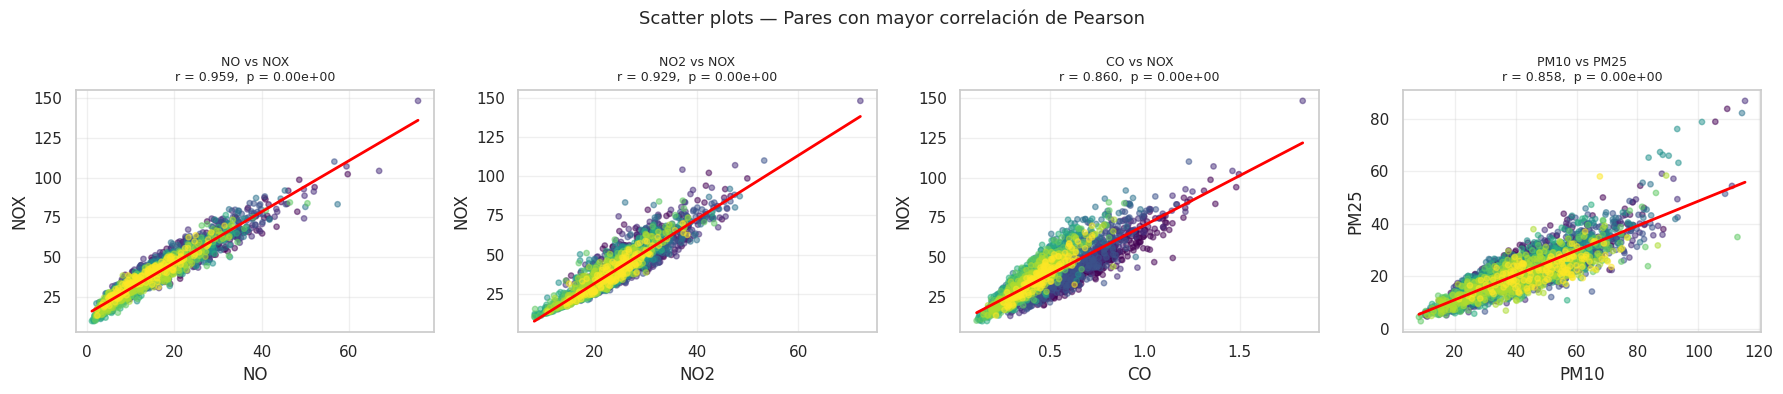

In [18]:
# Scatter plots de los pares más correlacionados
top_pares = sig[:4]  # Los 4 pares con mayor |r|

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (c1, c2, r, p) in zip(axes, top_pares):
    x, y = df[c1], df[c2]
    # Color por año
    sc = ax.scatter(x, y, c=df['anio'], cmap='viridis', alpha=0.5, s=15)
    # Línea de regresión
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs + b, color='red', lw=2)
    ax.set_xlabel(c1)
    ax.set_ylabel(c2)
    ax.set_title(f'{c1} vs {c2}\nr = {r:.3f},  p = {p:.2e}', fontsize=9)

plt.suptitle('Scatter plots — Pares con mayor correlación de Pearson', fontsize=13)
plt.tight_layout()
plt.savefig('fig_scatter_pares.png', dpi=150, bbox_inches='tight')
plt.show()

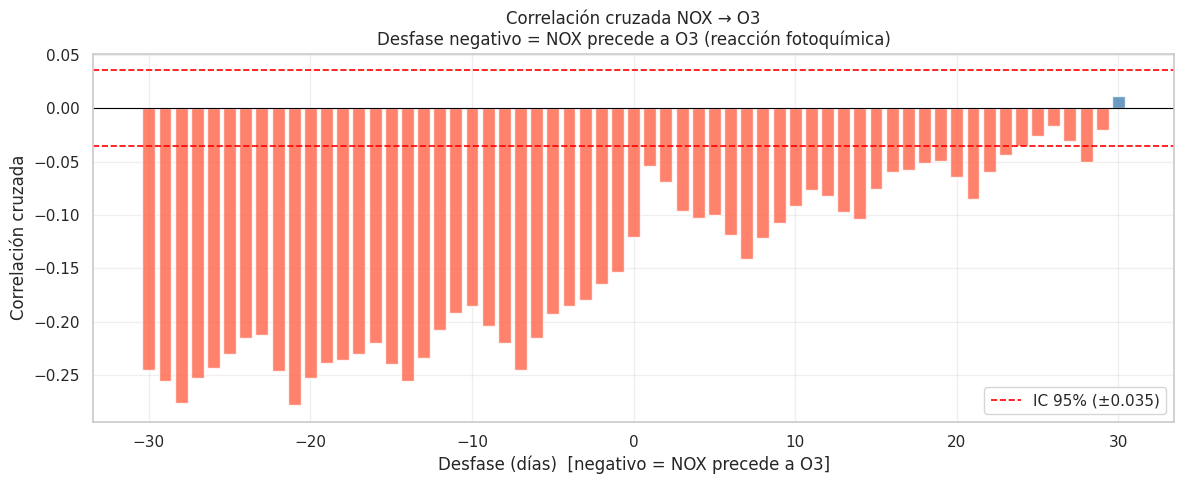

Desfase con mayor correlación: -21 días
Esto confirma si NOX precede (lag < 0) o sigue (lag > 0) al O3.


In [19]:
# Correlación cruzada (cross-correlation) con desfase temporal
# ¿Los NOX de hoy predicen el O3 de mañana? (reacción fotoquímica con desfase)
par_1, par_2 = 'NOX', 'O3'

x = (df[par_1] - df[par_1].mean()) / df[par_1].std()
y = (df[par_2] - df[par_2].mean()) / df[par_2].std()
n = len(x)

lags   = np.arange(-30, 31)
xcorr  = [x.iloc[max(0,-lag):n-max(0,lag)].values @
           y.iloc[max(0,lag):n-max(0,-lag)].values / n
           for lag in lags]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lags, xcorr, color=np.where(np.array(xcorr) >= 0, 'steelblue', 'tomato'), alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
# Bandas de confianza al 95%
conf = 1.96 / np.sqrt(n)
ax.axhline(conf,  color='red', linestyle='--', lw=1.2, label=f'IC 95% (±{conf:.3f})')
ax.axhline(-conf, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Desfase (días)  [negativo = NOX precede a O3]')
ax.set_ylabel('Correlación cruzada')
ax.set_title(f'Correlación cruzada {par_1} → {par_2}\n'
             f'Desfase negativo = {par_1} precede a {par_2} (reacción fotoquímica)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('fig_cross_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

lag_max = lags[np.argmax(np.abs(xcorr))]
print(f'Desfase con mayor correlación: {lag_max} días')
print(f'Esto confirma si NOX precede (lag < 0) o sigue (lag > 0) al O3.')

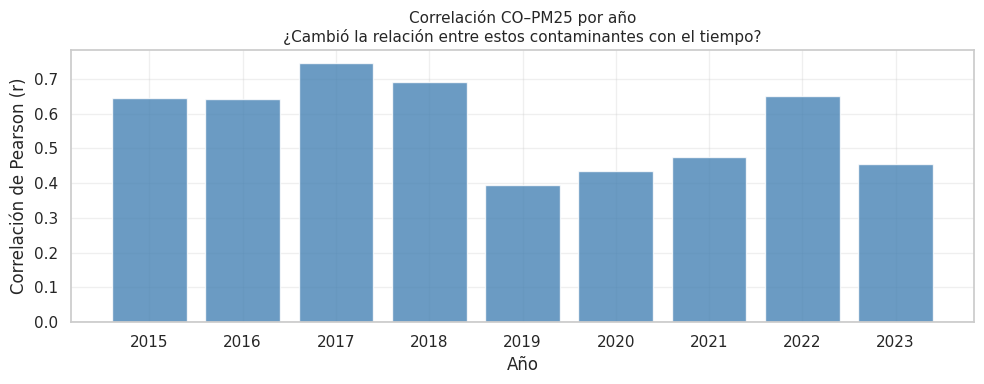

In [20]:
# Correlación por año: ¿cambió la relación entre contaminantes con el tiempo?
corr_por_anio = df.groupby('anio')[CONTAMINANTES].apply(
    lambda g: g.corr().loc['CO', 'PM25']
).reset_index()
corr_por_anio.columns = ['anio', 'r_CO_PM25']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(corr_por_anio['anio'], corr_por_anio['r_CO_PM25'],
       color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Año')
ax.set_ylabel('Correlación de Pearson (r)')
ax.set_title('Correlación CO–PM25 por año\n¿Cambió la relación entre estos contaminantes con el tiempo?', fontsize=11)
ax.set_xticks(corr_por_anio['anio'])
plt.tight_layout()
plt.savefig('fig_correlacion_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumen del análisis

| # | Análisis | Técnica | Tema del curso |
|---|---------|---------|----------------|
| 1 | Reducción de dimensionalidad | PCA sobre matriz M estandarizada | PCA |
| 2 | Visualización scree + biplot | Varianza explicada + loadings | PCA |
| 3 | Proyección preservando distancias | MDS métrico (distancias euclidianas) | Escalamiento multidimensional |
| 4 | Proyección ponderando distancias locales | Mapeo de Sammon (L-BFGS-B) | Mapeo de Sammon |
| 5 | Identificación de ciclos dominantes | FFT con retiro de tendencia + ventana Hann | Análisis espectral |
| 6 | Reconstrucción de señal | FFT inversa con k armónicos | Análisis espectral |
| 7 | Relaciones lineales entre contaminantes | Pearson + prueba t (p-value) | Correlación |
| 8 | Desfase entre contaminantes | Correlación cruzada con bandas de confianza | Correlación |
| 9 | Evolución temporal de correlaciones | Pearson agrupado por año | Correlación |